In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [3]:
start_year = 2004
end_year = 2014
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_drug_reaction_associations.csv'

In [5]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna()
preds.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff
0,amoxicillin,cardio-respiratory arrest,All,0,18,12062,24,19398,1.206143,1.205836,0.003389,39.0,21483.0,5200.0,4963497.0,1.732823,1.731495,0.001549,0.001490,-0.361812
1,amoxicillin,inguinal hernia,All,0,6,12074,5,19417,1.929800,1.929338,0.006226,13.0,21509.0,835.0,4967862.0,3.595888,3.594320,0.002192,0.000497,-0.622178
2,amoxicillin,diarrhoea haemorrhagic,All,0,23,12057,14,19408,2.644486,2.641355,0.016796,33.0,21489.0,1751.0,4966946.0,4.356132,4.350986,0.004094,0.001904,-0.499110
3,amoxicillin,blood creatine phosphokinase increased,All,0,44,12036,35,19387,2.024944,2.021211,0.017891,81.0,21441.0,11042.0,4957655.0,1.696167,1.693547,0.002142,0.003642,0.176872
4,amoxicillin,injection site pain,All,0,34,12046,192,19230,0.282692,0.284711,-0.040739,41.0,21481.0,35493.0,4933204.0,0.265287,0.266687,-0.004082,0.002815,0.065402


In [6]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [18]:
# merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
# merged = merged[merged['replicate']==1]
# merged['label'] = merged['label'].fillna(0)
# merged.head()

0.7274848187509819
0.07804432629693708


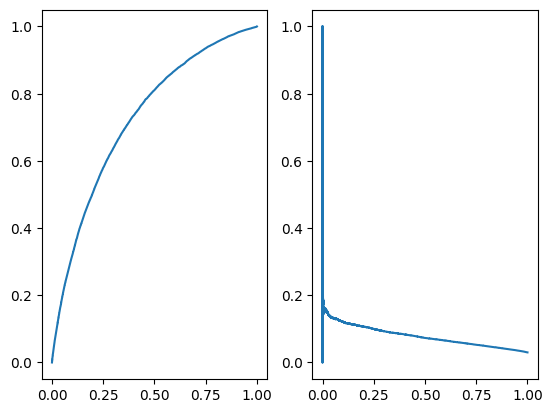

In [20]:
col = 'mean'
rep = 1

merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
merged = merged[merged['replicate']==rep]
merged['label'] = merged['label'].fillna(0)

print(metrics.roc_auc_score(merged['label'], merged[col]))
print(metrics.average_precision_score(merged['label'], merged[col]))
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr)

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr)


In [21]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()

(0.004076627285433291, 0.01125083512238778)